# Process-driven local bandwdith inference

In [1]:
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset

## Prepare Dataser

Create y = beta1 * x1 + err, where x1 and err are randomly drawn from normal distribution

and beta1 is a composite GRF comes with different rate of change

In [2]:
k = 1
field_size = 60
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    useIntercept=False
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(X, beta)

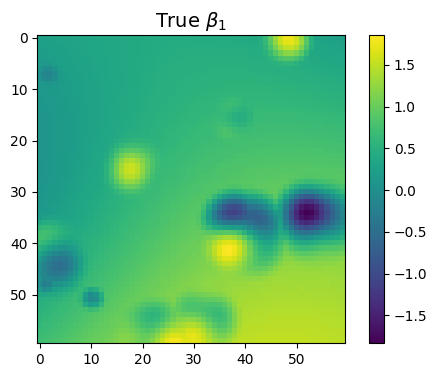

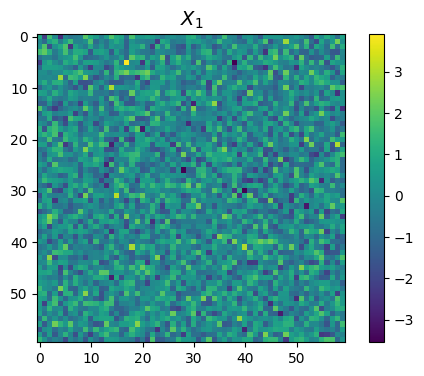

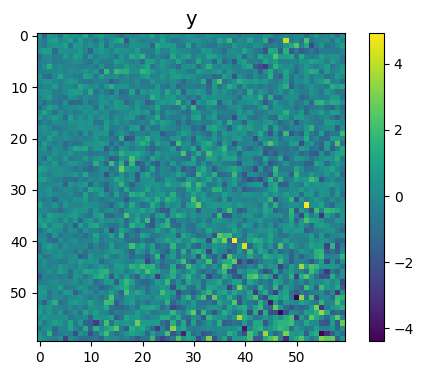

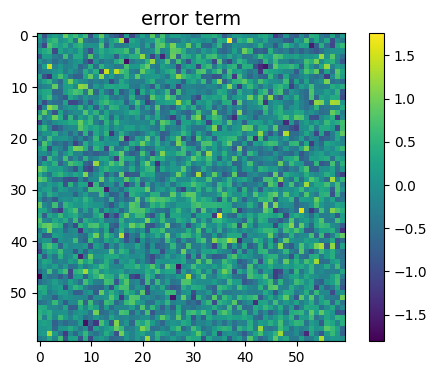

In [3]:
# Plot data in 2D graphs
dataset.plot(
    b=beta.T,
    sub_title=[r"True $\beta_1$"],
    size=field_size
)
dataset.plot(
    b=X.T,
    sub_title=[r"$X_1$"],
    size=field_size
)
dataset.plot(
    b=y.reshape(1, -1),
    sub_title=['y'],
    size=field_size
)
dataset.plot(
    b=err.reshape(1, -1),
    sub_title=['error term'],
    size=field_size
)

In [4]:
# Plot true process in 3D graph
fig = dataset.plot_process_3d(
    beta,
    title="True process (beta field)",
    show=True,
    # save_html="beta_surface.html"    
)

#### Stage 1: Global Bandwidth and Uncertainty Quantification

We begin by fitting a conventional GWR model using a single global bandwidth selected by minimizing the AICc criterion.
While a single optimal bandwidth is often treated as a point estimate of the spatial scale of the underlying process, recent work has shown that bandwidth selection is subject to non-negligible uncertainty.

Following Li et al. (2020), we compute a confidence interval (CI) for the bandwidth, which defines a range of smoothing scales that are statistically indistinguishable in terms of model fit.
This interval will later serve as the admissible domain for local bandwidth inference.

In [5]:
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

g_X = dataset.X
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()

# Select global bandwidth
selector = Sel_BW(g_coords, g_y, g_X, constant=False)
bw_opt = selector.search()

# Fit GWR at optimal bandwidth
gwr = GWR(g_coords, g_y, g_X, bw=bw_opt, constant=False)
gwr_res = gwr.fit()

# Bandwidth confidence interval (Li et al., 2020)
bw_ci = gwr_res.get_bws_intervals(selector, level=0.95)

print(f"The optimal global bandwidth : {bw_opt}")
print(f"The bandwidth confidence interval of this process : {bw_ci}")


The optimal global bandwidth : 69.0
The bandwidth confidence interval of this process : (60.0, 69.0)


In [6]:

g_X = dataset.X
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()


print(X)
print(err)
print(beta)
print(g_y)
# fig = dataset.plot_process_3d(
#     gwr_res.params[:, 0],
#     title="True process (beta field)",
#     show=True,
#     # save_html="beta_surface.html"    
# )

[[ 0.89603995]
 [-2.12394854]
 [ 1.64020381]
 ...
 [ 1.73986917]
 [-1.02124483]
 [ 0.31536862]]
[[ 0.33010556]
 [-0.88293585]
 [-0.04019969]
 ...
 [ 0.08623259]
 [ 0.04453311]
 [-0.0306394 ]]
[[0.26303906]
 [0.27154806]
 [0.27839383]
 ...
 [1.48615126]
 [1.4786851 ]
 [1.47109732]]
[[ 0.56579907]
 [-1.45968995]
 [ 0.41642293]
 ...
 [ 2.67194134]
 [-1.46556641]
 [ 0.43329853]]
